## Task


The aim of the assignment is to apply the NLP techniques you have learnt in class to analyse one of the 
datasets described below.   
• Note: some of the datasets are quite large, so you may need to sample a small percentage of the 
data and work that. 
The exact tasks performed may depend on the dataset chosen, but we would expect to see some of the 
following: 
#### 1. Preliminary analysis:  
Briefly describe the data:

What is the structure of the dataset? What type of task was the dataset collected for? 

What type of documents does it contain? How many are there? How long are they on average and 

what is their distribution? 

How big is the vocabulary of the collection? How big is the vocabulary of a document on average? 

Play around with documents using code from the early parts of the course. For example, you could:
Cluster the documents, visualise the clusters and to try to understand what types of groups are 
present.

Index the documents so that you can perform keyword search over them. 

Train a Word2Vec embedding and investigate the properties of the resulting embedding. 
#### 2. Training models: 
Each dataset has been created with a particular task in mind. You don’t necessarily need to tackle that 
particular problem, but you do need to train some model(s) on the data:

train ML models (e.g. a linear classifier, an LSTM and/or a Transformer) to perform a particular 

task on the data; 
if possible, try to fine-tune a pretrained models on the same task and compare their performance; 

try an LLM on the task, comparing one, few and zero-shot performance;  
and perhaps even try to fine-tune a small LLM on the task (if it makes sense to do so).   
#### 3. Possible extensions: 
Depending on the dataset chosen there will be many additional investigations that you could perform, 
for example:  
- investigate another task on the same dataset  
- investigate the same task on a related dataset 
- use text-to-speech and speech-to-text models to create a voice interactive chatbot
- create your own dialog dataset by transcribing audio conversations (e.g. using MS Teams).  

In [116]:
!pip install faiss-cpu
!pip install -q bertviz
!pip install bertopic[all] datasets
!pip install evaluate rouge_score

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# 1. Preliminary analysis

## 1.a) Data Exploration

### Import the dataset and visualizing its structure

Import the general necessary libraries ( the specific libraries will be imported later in the cells where they are used)

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random
from collections import Counter
from textblob import TextBlob
from tqdm import tqdm

In [118]:
from datasets import load_dataset

dataset = load_dataset("neural-bridge/rag-dataset-12000")

In [119]:
dataset

DatasetDict({
    train: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 9600
    })
    test: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 2400
    })
})

They are already divided into train and test set. So we just need to convert them to Pandas Dataframes.

In [120]:
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

In [121]:
print('Train dataset len:', len(train_df))
print('Test dataset len:', len(test_df))

Train dataset len: 9600
Test dataset len: 2400


In [122]:
train = dataset['train']
test = dataset['test']

Let's then print a complete (question, context, answer) sample of our dataset

In [123]:
# Show an example

context = train_df['context'][1]
question = train_df['question'][1]
answer = train_df['answer'][1]

print(f"\nQuestion\n")
print(f"{question}\n")
print("------------------------------------------------------------------------")
#print(f"\nContext\n")
#print(f"{context}\n")
print("------------------------------------------------------------------------")
print(f"\nAnswer\n\n")
print(answer)


Question

What are some of the benefits reported from having access to Self-supply water sources?

------------------------------------------------------------------------
------------------------------------------------------------------------

Answer


Benefits reported from having access to Self-supply water sources include convenience, less time spent for fetching water and access to more and better quality water. In some areas, Self-supply sources offer important added values such as water for productive use, income generation, family safety and improved food security.


In [216]:
# Count NaN / null values per column for train set
train_null_counts = train_df.isna().sum()

# Count NaN / null values per column for test set
test_null_counts = test_df.isna().sum()

null_counts = train_null_counts + test_null_counts
# Print the result
print(f"NaN/null values per column: \n{null_counts}")
print(f"NaN/null values per column in train: \n{train_null_counts}")
print(f"NaN/null values per column in test: \n{test_null_counts}")


train_df = train_df.dropna()
test_df = test_df.dropna()

train_df = train_df.reset_index()
test_df = test_df.reset_index()

print('Any missing values: ')
print(train_df.isnull().any() & test_df.isnull().any())

NaN/null values per column: 
context     0
question    0
answer      0
dtype: int64
NaN/null values per column in train: 
context     0
question    0
answer      0
dtype: int64
NaN/null values per column in test: 
context     0
question    0
answer      0
dtype: int64
Any missing values: 
index       False
context     False
question    False
answer      False
dtype: bool


### Tokenization and data visualization

We are going to tokenize the dataset and visualize their distributions

In [125]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
# stemmer = PorterStemmer()

context_lengths = []
question_lengths = []
vocab = set()

all_tokens = []

train_df_tokenized = []

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalnum()]  # Remove punctuation
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    # tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return tokens

def append_tokens(entry):
    context_tokens = preprocess(entry['context'])
    question_tokens = preprocess(entry['question'])
    answer_tokens = preprocess(entry['answer'])
    
    context_lengths.append(len(context_tokens))
    question_lengths.append(len(question_tokens))
    vocab.update(context_tokens)
    vocab.update(question_tokens)

    all_tokens.extend(context_tokens)
    all_tokens.extend(question_tokens)

    train_df_tokenized.append({'context': context_tokens, 'question': question_tokens, 'answer': answer_tokens})

def preprocess_to_string(text):
    text = text.replace('\n', ' ')
    tokens = preprocess(text)
    return ' '.join(tokens)


train_df.apply(lambda entry: append_tokens(entry), axis=1)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0       None
1       None
2       None
3       None
4       None
        ... 
9595    None
9596    None
9597    None
9598    None
9599    None
Length: 9598, dtype: object

In [126]:
train_df_tokenized = pd.DataFrame(train_df_tokenized, columns=['context', 'question', 'answer'])
train_df_tokenized.head()

,context,question,answer
0,"[caption, tasmanian, berry, grower, nic, hanse...","[berry, export, summary, 2028, purpose]","[berry, export, summary, 2028, dedicated, expo..."
1,"[rwsn, collaborations, southern, africa, study...","[benefits, reported, access, water, sources]","[benefits, reported, access, water, sources, i..."
2,"[android, applications, categories, descriptio...","[unique, features, coolands, twitter, app]","[unique, features, coolands, twitter, app, inc..."
3,"[unequal, india, question, simple, answer, 60,...","[main, difference, national, sample, survey, n...","[main, difference, nss, ihds, terms, measuring..."
4,"[gunnar, nelson, took, time, feet, zak, cummin...","[gunnar, nelson, win, fight, zak, cummings, uf...","[gunnar, nelson, fight, zak, cummings, ufc, fi..."


### Analysis of Token Frequencies (TF-IDF)

In [127]:
from sklearn.feature_extraction.text import TfidfVectorizer

train_df_tokenized['context_str'] = train_df_tokenized['context'].apply(lambda tokens: ' '.join(tokens))
train_df_tokenized['question_str'] = train_df_tokenized['question'].apply(lambda tokens: ' '.join(tokens))

# TF-IDF on contexts only
vectorizer_context = TfidfVectorizer()
tfidf_context = vectorizer_context.fit_transform(train_df_tokenized['context_str'])

# TF-IDF on questions only
vectorizer_question = TfidfVectorizer()
tfidf_question = vectorizer_question.fit_transform(train_df_tokenized['question_str'])

# TF-IDF on combined contexts + questions
train_df_tokenized['combined'] = train_df_tokenized['context_str'] + ' ' + train_df_tokenized['question_str']
vectorizer_combined = TfidfVectorizer()
tfidf_combined = vectorizer_combined.fit_transform(train_df_tokenized['combined'])

We can see that the tf-idf matrix is much thinner than the question one. This is natural since the context has a much bigger vocabulary. 
\
Another interesting thing to point out is that the matrix due to the combination of both question and context is slightly wider than the context one because most of the words contained in the questions are also contained in the context.

In [128]:
tfidf_question_df = pd.DataFrame(tfidf_question.toarray(), columns=vectorizer_question.get_feature_names_out())
tfidf_context_df = pd.DataFrame(tfidf_context.toarray(), columns=vectorizer_context.get_feature_names_out())
tfidf_combined_df = pd.DataFrame(tfidf_combined.toarray(), columns=vectorizer_combined.get_feature_names_out())

Let's visualize through a histogram the most frequent word in the contexts

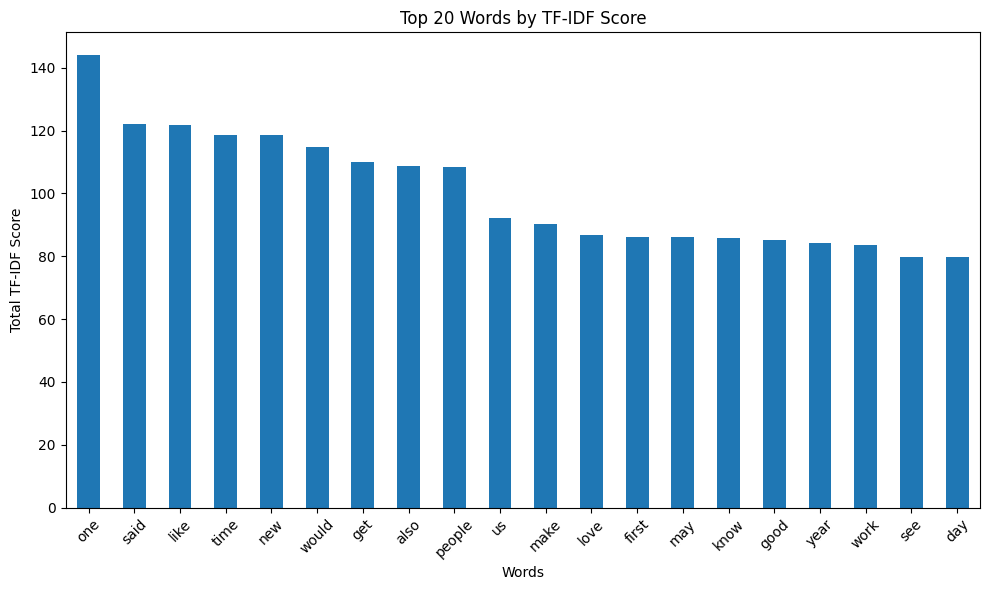

In [129]:
word_scores = tfidf_context_df.sum(axis=0).sort_values(ascending=False)

top_n = 20
top_words = word_scores.head(top_n)

plt.figure(figsize=(10, 6))
top_words.plot(kind='bar')
plt.title(f"Top {top_n} Words by TF-IDF Score")
plt.xlabel("Words")
plt.ylabel("Total TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [130]:
feature_names = vectorizer_context.get_feature_names_out()

def get_top_n_words(row, n):
    row_data = row.toarray().flatten()
    top_indices = row_data.argsort()[::-1][:n]
    
    return [(feature_names[i], row_data[i]) for i in top_indices if row_data[i] > 0]

N = 5
train_df_tokenized[f'top_{N}_tfidf_words_context'] = [
    get_top_n_words(tfidf_context[i], N) for i in range(tfidf_context.shape[0])
]

Let's see the most frequent words (calculated through  tf-idf score) for each context

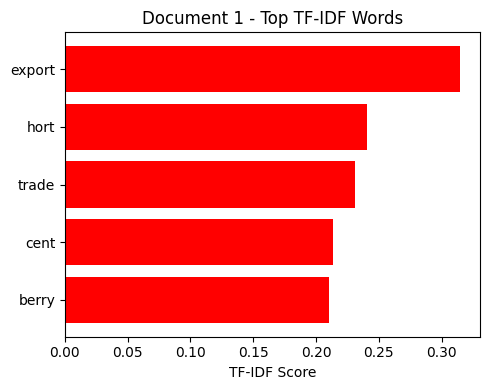

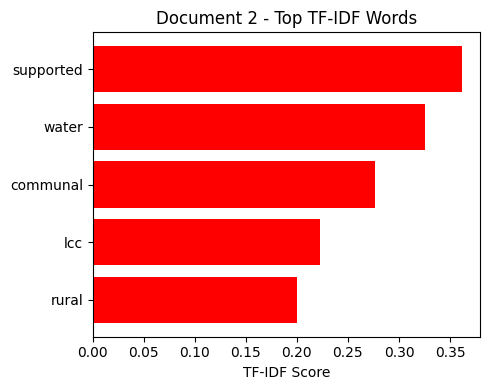

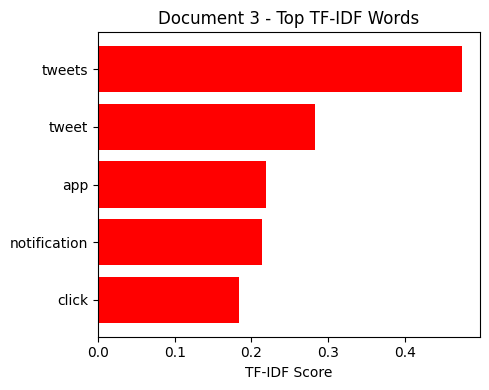

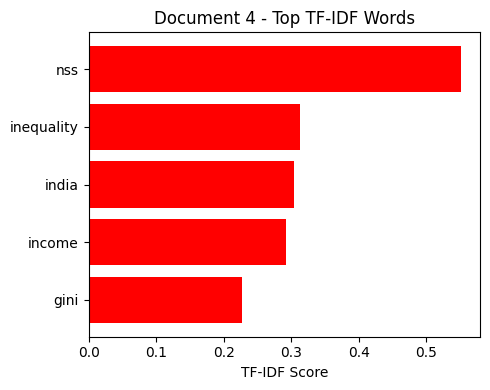

In [131]:
def plot_top_words_with_scores(word_score_pairs, title='Top TF-IDF Words'):
    words, scores = zip(*word_score_pairs)
    plt.figure(figsize=(5, 4))
    plt.barh(words[::-1], scores[::-1], color='red')  # reverse for descending order
    plt.xlabel('TF-IDF Score')
    plt.title(title)
    plt.tight_layout()
    plt.show()

for i in range(4):
    plot_top_words_with_scores(train_df_tokenized.loc[i, f'top_{N}_tfidf_words_context'],
                           title=f'Document {i+1} - Top TF-IDF Words')

Now instead let's visualize the most frequent tokens contained in the train set including all of the columns (question, context, answer)

In [132]:
fdist = FreqDist(all_tokens)

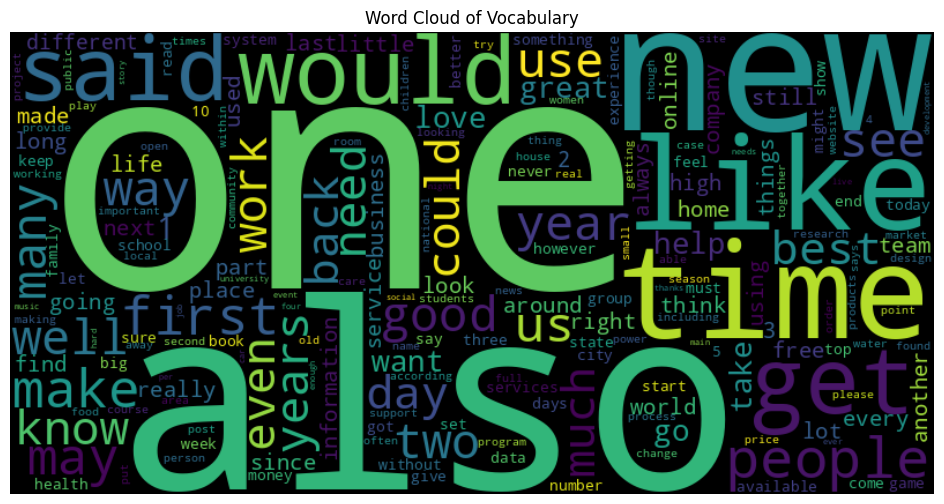

In [133]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(fdist)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Vocabulary")
plt.show()

<Axes: title={'center': 'Top 30 Most Frequent Words'}, xlabel='Samples', ylabel='Counts'>

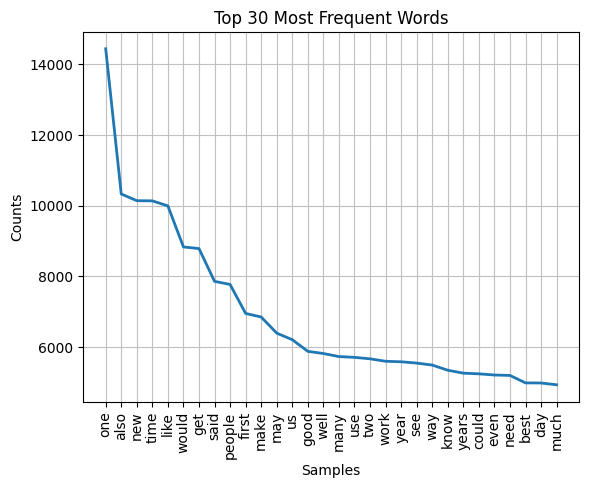

In [134]:
fdist.plot(30,  title="Top 30 Most Frequent Words")

There are lots of words that appear just once. Let's count them

In [135]:
least_freq_1_words = [word for word, freq in fdist.items() if freq == 1 and word.isalpha()]
print(len(least_freq_1_words))

52886


These are some of the words that appear only once.

Now we'd like to produce some statistics on the length of the contexts and questions.

Number of documents: 9598
Average context length: 321.12 tokens
Average question length: 6.81 tokens
Vocabulary size: 128313


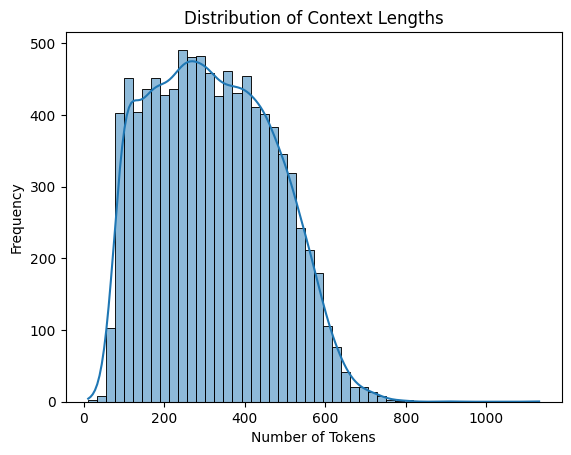

In [136]:
print(f"Number of documents: {len(train_df)}")
print(f"Average context length: {sum(context_lengths)/len(context_lengths):.2f} tokens")
print(f"Average question length: {sum(question_lengths)/len(question_lengths):.2f} tokens")
print(f"Vocabulary size: {len(vocab)}")

sns.histplot(context_lengths, bins=50, kde=True)
plt.title('Distribution of Context Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

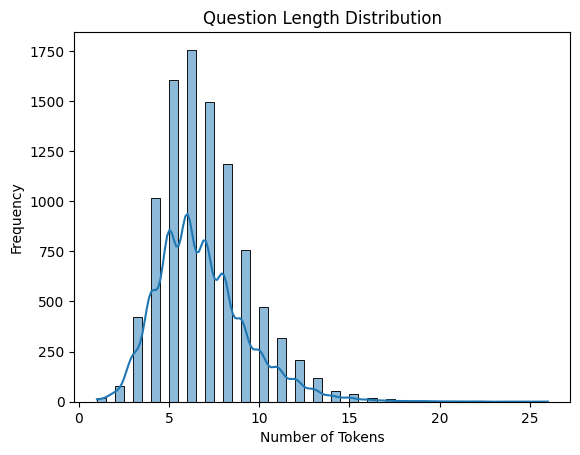

In [137]:
sns.histplot(question_lengths, bins=50, kde=True)
plt.title("Question Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

## 1.b) Data cleaning

In [138]:
tokenized_contexts = train_df_tokenized['context']
tokenized_questions = train_df_tokenized['question']
tokenized_answers = train_df_tokenized['answer']

print(len(tokenized_questions))
print(len(tokenized_contexts))
print(len(tokenized_answers))

9598
9598
9598


Create the vector to feed the Word2Vec model in such a way to have (question, context, answer). \
There are other possibilities to form the vector to feed to the model (e. g. the one commented out ) they all perform pretty well and more or less the same

In [139]:
all_tokenized_sentences = [ c + q + a for c, q, a in zip(tokenized_contexts.tolist(), tokenized_questions.tolist(), tokenized_answers.tolist()) ]

# all_tokenized_sentences = tokenized_contexts.tolist() + tokenized_questions.tolist() + tokenized_answers.tolist() # ther possibility performing worse

### Drop the words occurring once

Convert least_freq_1_words to a set because it is much faster to search in it and then filter out all the words that occurr once (N.T. all the words not the numbers)

In [140]:
least_freq_1_words = set(least_freq_1_words)
all_tokenized_sentences = [ [ word for word in sentence if word not in least_freq_1_words ] for sentence in all_tokenized_sentences ]


### Create embeddings with Word2Vec 



In [141]:
from gensim.models.word2vec import Word2Vec

d = 30 # dimension of the embeddings

model = Word2Vec(all_tokenized_sentences, vector_size=d, min_count=5, window=10)

In [142]:
len(model.wv)

# print(model.wv.key_to_index) # output is too long

38679

In [143]:
term = 'house'
model.wv[term]
model.wv.most_similar(term)

[('apartment', 0.7550865411758423),
 ('townhouses', 0.7016996145248413),
 ('residence', 0.6934137940406799),
 ('neighborhood', 0.678960382938385),
 ('owner', 0.6641939282417297),
 ('town', 0.6577368974685669),
 ('doors', 0.6552903652191162),
 ('farm', 0.6495755910873413),
 ('nando', 0.648603618144989),
 ('door', 0.6421513557434082)]

In [144]:
seed = random.seed(0)

sample = random.sample(list(model.wv.key_to_index), 1000)
word_vectors = model.wv[sample]

### 1.c) Data visualization

We are adopting t-sne to visuzlize in 3D the token's embeddings generated by Word2Vec

In [145]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, n_iter=2000)
tsne_embedding = tsne.fit_transform(word_vectors)

In [146]:
x, y, z = np.transpose(tsne_embedding)

In [147]:
fig = px.scatter_3d(x=x[:200],y=y[:200],z=z[:200],text=sample[:200])
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

In [148]:
colours = ['red','green','blue','orange','yellow','purple','pink','cream','brown','black','white','gray']

word_vectors = model.wv[colours+sample]

tsne = TSNE(n_components=3)
tsne_embedding = tsne.fit_transform(word_vectors)

x, y, z = np.transpose(tsne_embedding)

Here we can see that all colors are embedded in the same region of space, thus similarity in meaning is translated in locality in the t-sne space

In [149]:
r = (-200,200)
fig = px.scatter_3d(x=x, y=y, z=z, range_x=r, range_y=r, range_z=r, text=colours + [None] * 1000)
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

### 1.d) Clustering

Now that we have the embeddings of the words, we would like to make operations fast with them. \
Faiss is a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM. It also contains supporting code for evaluation and parameter tuning. \
Faiss is written in C++ with complete wrappers for Python/numpy. Some of the most useful algorithms are implemented on the GPU. It is developed primarily at Meta's Fundamental AI Research group. \
Let's install it and try to make a search!

In [150]:
import faiss
index = faiss.IndexFlatL2(d) 

In [151]:
# This creates a matrix with the embeddings of the words as rows
words = list(model.wv.key_to_index.keys())
word_vectors = np.array([model.wv[word] for word in words]).astype("float32") 

# This creates an index 
index = faiss.IndexFlatL2(word_vectors.shape[1])
index.add(word_vectors)

In [152]:
# Let's perform a search
query_word = 'house'
query_vector = np.array([model.wv[query_word]]).astype("float32")
D, I = index.search(query_vector, k=10)  # D = distances, I = indices
similar_words = [words[i] for i in I[0]]
print(f"Words similar to '{query_word}':", similar_words)

Words similar to 'house': ['house', 'apartment', 'owner', 'residence', 'doors', 'neighborhood', 'farm', 'opened', 'cat', 'creek']


Let's create a function that shows examples of clusters

In [153]:
def show_cluster_examples(column, n_clusters=5, top_n=30):
    if column == "question": 
        df = pd.DataFrame({column: tokenized_questions, 'cluster': labels})   
    elif column == "context": 
        df = pd.DataFrame({column: tokenized_context, 'cluster': labels})
    elif column == "answer": 
        df = pd.DataFrame({column: tokenized_answers, 'cluster': labels})
    
    unique_clusters = sorted(df['cluster'].unique())
    clusters_to_show = unique_clusters[:n_clusters]

    for i in clusters_to_show:
        print(f"\n Cluster {i} (size={len(df[df.cluster==i])}):")
        examples = df[df.cluster == i][column].sample(min(top_n, len(df[df.cluster == i])), random_state=0)
        for q in examples:
            print("  -", q)

Let's now use the embeddings of the words provided by Word2Vec. \
The Word2Vec gives us the embeddings of words, now we have to compute the embeddings of sentences to then compare them and cluster them. 
We use the mean of the embedding of the words to form the embeddings of the sentence (N.T. We could have also used the sum).

In [154]:
def sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

question_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_questions])
context_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_contexts])
answer_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_answers])

This is a function to guess the magnitude of k. It works in this way, we calculate the cosine similarity of the sentences embeddings and count them 

In [155]:
from sklearn.cluster import KMeans

def cosine_similarity_faiss(vectors):
    vectors = np.asarray(vectors).astype('float32')
    normalized = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    similarity_matrix = np.matmul(normalized, normalized.T) 
    return similarity_matrix

def extract_similar_pairs(sim_matrix, threshold):
    n = sim_matrix.shape[0]
    similar_pairs = []

    for i in range(1, n):
        for j in range(i):
            if sim_matrix[i, j] > threshold:
                similar_pairs.append((i, j, sim_matrix[i, j]))
    l = len(similar_pairs)
    print(f"Sim pairs: {l}")
    return l

def sim_matrix_density(embeddings, threshold=0.8):
    S = cosine_similarity_faiss(embeddings)
    print(S.shape)
    l = extract_similar_pairs(S, threshold)
    return l/(S.shape[0] * S.shape[1])*100, S

The idea of having the sim_matrix_density function is to have an idea of which percentage of the sentences is similar. \
In this way it is possible to get a small indicator of the number of the topics. \
The bigger the percentage the less the topics

In [156]:
perc, S = sim_matrix_density(question_embeddings, 0.7) 

/tmp/ipykernel_31/755631085.py:5: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_31/755631085.py:5: RuntimeWarning:

invalid value encountered in divide



(9598, 9598)


/tmp/ipykernel_31/755631085.py:15: RuntimeWarning:

invalid value encountered in greater



Sim pairs: 851857


In [157]:
print(f"The percentage of similar entries of the similarity matrix is {perc:.2f}%")

The percentage of similar entries of the similarity matrix is 0.92%


/tmp/ipykernel_31/755631085.py:5: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_31/755631085.py:5: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning:

invalid value encountered in greater_equal

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning:

invalid value encountered in less_equal



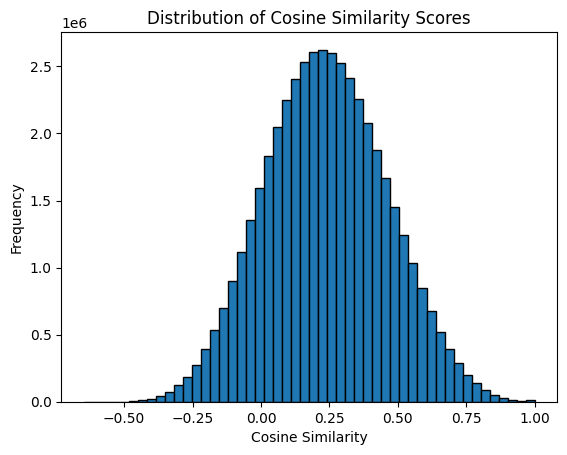

In [158]:
S = cosine_similarity_faiss(question_embeddings)

upper_triangle = S[np.triu_indices_from(S)]

plt.hist(upper_triangle, bins=50, edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

### Elbow method

Using the elbow visualization, we can predict the empirical number of clusters in our dataset

100%|██████████| 42/42 [03:26<00:00,  4.91s/it]


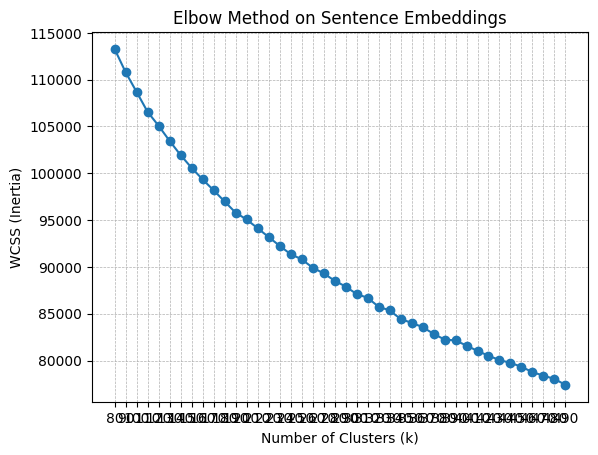

In [159]:
k_values = range(80, 500, 10)
wcss = []

for k in tqdm(k_values):
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans.fit(question_embeddings)
    wcss.append(kmeans.inertia_)

plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method on Sentence Embeddings")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(min(k_values), max(k_values) + 1, 10))
plt.show()

In [160]:
k = 250

Using the K-means algorithm, we can iteratively predict the centroids of our clusters

In [161]:
# 250 - 300 working fine
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(question_embeddings)

In [162]:
show_cluster_examples('question')


 Cluster 0 (size=20):
  - ['narrator', 'wife', 'go', 'honeymoon']
  - ['founded', 'family', 'dog', 'rescue']
  - ['happened', 'burrell', 'family', 'stingray', 'bay']
  - ['activities', 'narrator', 'saying', 'goodbye', 'parents']
  - ['narrator', 'decide', 'buy', 'home', 'mother']
  - ['event', 'prompted', 'knebel', 'family', 'family', 'portraits', 'made']
  - ['special', 'gift', 'daughter', 'gave', 'mother', 'valentine', 'day']
  - ['alice', 'unique', 'way', 'bypassing', 'family', 'christmas', 'gift', 'rule']
  - ['narrator', 'planning', 'paris', 'dad']
  - ['eldest', 'child', 'goodwin', 'family']
  - ['rebekah', 'holston', 'daniel', 'fleming', 'parents', 'get', 'married']
  - ['suggestions', 'decorating', 'teenager', 'birthday', 'party', 'home']
  - ['narrator', 'friend', 'bring', 'house', 'sick']
  - ['meals', 'mother', 'prepares', 'son']
  - ['came', 'idea', 'christmas', 'play', 'grace', 'baptist', 'church']
  - ['narrator', 'man', 'went', 'date', 'meet']
  - ['arrived', 'britney',

In [163]:
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(answer_embeddings)

In [164]:
show_cluster_examples('answer')


 Cluster 0 (size=24):
  - ['summit', 'eat', 'meals', 'high', 'calorie', 'nutritionally', 'balanced', 'freeze', 'dried', 'made', 'clean', 'ingredients', 'offer', 'excellent', 'nutrition', 'also', 'quick', 'easy', 'prepare', 'lightweight', 'satisfying', 'flavours', 'meals', 'clearly', 'labelled', 'nutritional', 'information', 'ingredients', 'also', 'easy', 'prepare', 'hot', 'water', 'packaging', 'reused', 'meals', 'also', 'noted', 'great', 'taste']
  - ['hypoallergenic', 'reduction', 'diet', 'recommended', 'dogs', 'food', 'allergies', 'involves', 'switching', 'food', 'one', 'contain', 'food', 'previously', 'allergic', 'brands', 'like', 'purina', 'pro', 'plan', 'uses', 'meat', 'vegetables', 'use', 'growth', 'hormones', 'food', 'also', 'recommended', 'severe', 'cases', 'veterinarian', 'may', 'recommend', 'prescription', 'diet']
  - ['author', 'suggests', 'integrating', 'multicolored', 'fruits', 'veggies', 'whole', 'grain', 'products', 'plenty', 'beans', 'peas', 'legumes', 'raw', 'unsalted

### Now we use a Sentence Transformer to create the embeddings 

In [165]:
print(tokenized_questions.tolist()[-10:])

[['name', 'beer', 'sunn', 'greg', 'anderson', 'helped', 'create', 'collaboration', 'right', 'proper', 'brewing', 'company', 'stone', 'brewing', 'pen', 'druid', 'brewing'], ['main', 'purpose', 'sun', 'microsystems', 'including', 'support', 'transactional', 'memory', 'rock', 'processors'], ['ways', 'students', 'extend', 'repeating', 'pattern', 'pat', 'clap', 'clap'], ['kellogg', 'company', 'argument', 'motion', 'limine', 'case', 'hoffman', 'la', 'roche', 'others'], ['purpose', 'test', 'method', 'described', 'context'], ['ways', 'lower', 'cost', 'teenager', 'car', 'insurance'], ['unique', 'action', 'taken', 'buyer', 'sale', 'first', 'farm'], ['vandam', 'cope', 'pressures', 'distractions', 'fishing', 'tournament'], ['program', 'written', 'author'], ['happens', 'player', 'mega', 'mushroom', 'effect', 'encounters', 'cars', 'trucks', 'moonview', 'highway', 'mario', 'kart', 'wii']]


In [166]:
tokenized_questions = tokenized_questions[tokenized_questions.apply(lambda x: len(x) > 3)]
tokenized_contexts = tokenized_contexts[tokenized_contexts.apply(lambda x: len(x) > 3)]
tokenized_answers = tokenized_answers[tokenized_answers.apply(lambda x: len(x) > 3)]

In [167]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2") 
question_embeddings = model.encode(tokenized_questions.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/284 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning:

invalid value encountered in greater_equal

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning:

invalid value encountered in less_equal



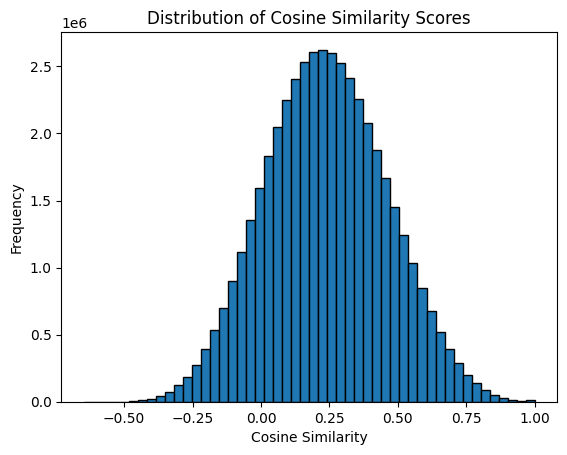

In [168]:
upper_triangle = S[np.triu_indices_from(S)]

plt.hist(upper_triangle, bins=50, edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

In [169]:
kmeans = KMeans(n_clusters=300, random_state=0)
labels = kmeans.fit_predict(question_embeddings)

In [170]:
show_cluster_examples('question', 10)


 Cluster 0 (size=33):
  - ['summer', 'school', 'math', 'english', 'science', 'credit', 'retrieval', 'take', 'place']
  - ['rules', 'groovy', 'compiled', 'bytecode']
  - ['fire', 'ice', 'heating', 'cooling', 'established']
  - ['sunset', 'slots', 'casino', 'established']
  - ['poem', 'april', '30', 'titled']
  - ['solar', 'heated', 'pool', 'work']
  - ['measures', 'winterwondergrass', 'festival', 'take', 'promote', 'sustainability']
  - ['wildfire', 'season', 'officially', 'end', 'santa', 'rosa']
  - ['real', 'salt', 'lake', 'record', 'hosting', 'mls', 'games', 'expansion', 'side', 'making', 'utah', 'debut']
  - ['sole', 'survivor', 'battle', 'jutland']
  - ['nyx', 'liquid', 'crystal', 'body', 'liner', 'infused']
  - ['recent', 'poem', 'written', 'laura', 'kennedy', 'according', 'list']
  - ['hottest', 'coldest', 'months', 'saucier', 'mississippi']
  - ['speculated', 'temperature', 'oven', 'context']
  - ['snowy', 'egrets', 'rare', 'late', '1800s']
  - ['cough', 'cold', 'remedies', 'ha

we create the answer embeddings using the Sentence Transformer and we are retrieving the clusters again with K-means

In [171]:
answer_embeddings = model.encode(tokenized_answers.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/296 [00:00<?, ?it/s]

In [172]:
kmeans = KMeans(n_clusters=300, random_state=0)
labels = kmeans.fit_predict(answer_embeddings)

In [173]:
show_cluster_examples('answer')


 Cluster 0 (size=37):
  - ['followers', 'dera', 'sacha', 'sauda', 'sect', 'ended', 'protests', 'authorities', 'assured', 'solution', 'would', 'found', 'regarding', 'screening', 'messenger', 'second', 'movie', 'starring', 'chief', 'godman', 'gurmit', 'ram', 'rahim', 'singh']
  - ['alinso', 'group', 'responsible', 'construction', 'works', 'tech', 'lane', 'ghent', 'logistics', 'zone']
  - ['clause', 'group', 'words', 'within', 'sentence', 'includes', 'subject', 'verb', 'phrase', 'group', 'related', 'words', 'within', 'sentence', 'subject', 'verb']
  - ['group', 'gay', 'federal', 'way', 'created', 'political', 'social', 'reasons', 'politically', 'remind', 'city', 'council', 'gay', 'people', 'live', 'federal', 'way', 'pay', 'taxes', 'taxes', 'go', 'diversity', 'funding', 'community', 'building', 'excludes', 'gay', 'people', 'socially', 'help', 'gay', 'individuals', 'connect', 'without', 'group', 'difficult', 'tell', 'else', 'gay', 'federal', 'way']
  - ['typical', 'group', 'sang', 'ballad'

# Training models

## GPU acceleration with CUDA if possible

In [174]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # accelerate on GPU if available

## Topic Modeling
### Leveraging BERT and Topic Modeling for Theme Discovery in QA Data
Semantic topic analysis of a question-answering (QA) dataset by applying BERT-based sentence embeddings and unsupervised topic modeling techniques.

The main steps include:

- generating dense embeddings from both the questions and their corresponding contexts using SentenceTransformer (BERT)

- applying a topic modeling algorithm separately to the questions and the contexts to identify dominant semantic clusters

- extracting and visualizing the top N topics among questions, along with their most representative keywords

- performing exploratory analysis

In [175]:
train_df_topic = train_df.copy()
train_df_topic["question"] = train_df["question"].apply(lambda x: preprocess_to_string(x))
train_df_topic["context"] = train_df["context"].apply(lambda x: preprocess_to_string(x))
train_df_topic["answer"] = train_df["answer"].apply(lambda x: preprocess_to_string(x))

train_df_topic

,context,question,answer
0,caption tasmanian berry grower nic hansen show...,berry export summary 2028 purpose,berry export summary 2028 dedicated export pla...
1,rwsn collaborations southern africa study revi...,benefits reported access water sources,benefits reported access water sources include...
2,android applications categories description co...,unique features coolands twitter app,unique features coolands twitter app include u...
3,unequal india question simple answer 60 years ...,main difference national sample survey nss ind...,main difference nss ihds terms measuring india...
4,gunnar nelson took time feet zak cummings toni...,gunnar nelson win fight zak cummings ufc fight...,gunnar nelson fight zak cummings ufc fight nig...
...,...,...,...
9595,teenagers getting first car right passage wait...,ways lower cost teenager car insurance,ways lower cost teenager car insurance include...
9596,sold farm farm 1 client central nebraska buyer...,unique action taken buyer sale first farm,buyer took brand new sign seller cut legs scre...
9597,entry 150 classic many boats following vandam ...,vandam cope pressures distractions fishing tou...,vandam copes pressures distractions fishing to...
9598,ok real interrupts actually system load wrote ...,program written author,program written author locks shell onto partic...


In [176]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [177]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model_context = BERTopic(embedding_model=embedding_model)
topics, probs = topic_model_context.fit_transform(train_df_topic["context"])

topic_model_question = BERTopic(embedding_model=embedding_model)
topics, probs = topic_model_question.fit_transform(train_df_topic["question"])

In [178]:
# show main topics
print(topic_model_context.get_topic_info())
print(topic_model_question.get_topic_info())

     Topic  Count                                  Name  \
0       -1   3958                -1_one_time_like_would   
1        0    256               0_music_album_song_band   
2        1    178             1_god_jesus_church_christ   
3        2    140           2_recipe_cheese_chicken_add   
4        3    137             3_film_movie_episode_show   
..     ...    ...                                   ...   
134    133     10    133_virus_computer_ransom_software   
135    134     10  134_programador_webcenter_para_busco   
136    135     10               135_mum_father_olu_judy   
137    136     10        136_jd_pricing_customer_orders   
138    137     10        137_por_moxie_lecture_students   

                                        Representation  \
0    [one, time, like, would, also, people, new, ge...   
1    [music, album, song, band, songs, piano, sound...   
2    [god, jesus, church, christ, lord, bible, us, ...   
3    [recipe, cheese, chicken, add, cup, cook, minu...   
4

In [179]:
# topic keyword
print(topic_model_context.get_topic(0))
print(topic_model_question.get_topic(0))

[('music', 0.02580557706576797), ('album', 0.01881935535427523), ('song', 0.01564611967494181), ('band', 0.015260801116308953), ('songs', 0.011520203122037352), ('piano', 0.009058845345791959), ('sound', 0.007780466638721871), ('musical', 0.007427091855352662), ('rock', 0.006961441573571249), ('tracks', 0.006594738184982998)]
[('context', 0.05864279118283604), ('mentioned', 0.046850270218289865), ('focus', 0.03177783826383394), ('essay', 0.0310483090772006), ('topic', 0.03007098478631846), ('research', 0.02182321802159201), ('programming', 0.019110663256547786), ('purpose', 0.018589030457288432), ('main', 0.01770164838200341), ('discussed', 0.01603588021408467)]


### Topic map and topic distribution for the context 

In [180]:
topic_model_context.visualize_topics()

In [181]:
topic_model_context.visualize_barchart(top_n_topics=12)

### Topic map and topic distribution for the question 

In [182]:
topic_model_question.visualize_topics()

In [183]:
topic_model_question.visualize_barchart(top_n_topics=12)

In [184]:
print("Topic number (context):", len(topic_model_context.get_topic_info()))
print("Topic number (question):", len(topic_model_question.get_topic_info()))

Topic number (context): 139
Topic number (question): 126


In [185]:
print("Main topics (context):")
print(topic_model_context.get_topic_info().head())

print("Main topics (question):")
print(topic_model_question.get_topic_info().head())

Main topics (context):
   Topic  Count                         Name  \
0     -1   3958       -1_one_time_like_would   
1      0    256      0_music_album_song_band   
2      1    178    1_god_jesus_church_christ   
3      2    140  2_recipe_cheese_chicken_add   
4      3    137    3_film_movie_episode_show   

                                      Representation  \
0  [one, time, like, would, also, people, new, ge...   
1  [music, album, song, band, songs, piano, sound...   
2  [god, jesus, church, christ, lord, bible, us, ...   
3  [recipe, cheese, chicken, add, cup, cook, minu...   
4  [film, movie, episode, show, series, season, f...   

                                 Representative_Docs  
0  [post likely nothing little pony show thought ...  
1  [last year trying book band show richmond furi...  
2  [sermon summary john face choice adam first fa...  
3  [top healthy summer recipes welcome gymcube pi...  
4  [heard james gunn yet assure certainly soon di...  
Main topics (question

### Retrieve unique words

In [186]:
def get_top_words(model, n_words=10):
    all_words = []
    for topic_id in model.get_topic_info()['Topic']:
        if topic_id == -1:  # Skip outliers
            continue
        words = [w[0] for w in model.get_topic(topic_id)[:n_words]]
        all_words.extend(words)
    return set(all_words)

words_question = get_top_words(topic_model_question)
words_context = get_top_words(topic_model_context)

print("Count of most important words (context):", len(words_context))
print("Count of most important words (question):", len(words_question))

Count of most important words (context): 1221
Count of most important words (question): 1143


### Hierarchical clustering

In [187]:
from scipy.cluster import hierarchy as sch

linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics_context = topic_model_context.hierarchical_topics(train_df_topic["context"], linkage_function=linkage_function)
hierarchical_topics_question = topic_model_question.hierarchical_topics(train_df_topic["question"], linkage_function=linkage_function)

100%|██████████| 124/124 [00:00<00:00, 272.07it/s]


### Show results on hierarchical clustering on context

In [188]:
topic_model_context.visualize_hierarchy(hierarchical_topics=hierarchical_topics_context)

### Show results on hierarchical clustering on question

In [189]:
topic_model_question.visualize_hierarchy(hierarchical_topics=hierarchical_topics_question)

### Retrieve top 3 topics among questions
We analyze the dataset to identify the three most frequent topics present in the questions. This helps us understand which areas users inquire about the most.

In [190]:
from collections import Counter

In [191]:
def get_top_n_topics(model, topics, n=3):
     # filter outliers topics
    filtered_topics = [t for t in topics if t != -1]
    
    counter = Counter(filtered_topics)
    top_n = counter.most_common(n)
    result = []
    for topic_id, count in top_n:
        keywords = model.get_topic(topic_id)
        result.append((topic_id, count, keywords))
    return result # return a list of tuples: (topic_id, count, keywords)

In [192]:
topics_question, _ = topic_model_question.fit_transform(train_df_topic["question"])
top_4 = get_top_n_topics(topic_model_question, topics_question, n=4)

for topic_id, count, keywords in top_4:
    print(f"Topic {topic_id} (count: {count}):")
    print([word for word, _ in keywords])
    print()

Topic 0 (count: 209):
['context', 'mentioned', 'focus', 'essay', 'topic', 'research', 'mean', 'purpose', 'main', 'discussing']

Topic 1 (count: 187):
['amenities', 'hotel', 'offer', 'guests', 'resort', 'inn', 'provided', 'apartment', 'available', 'apartments']

Topic 2 (count: 181):
['music', 'album', 'song', 'band', 'released', 'musical', 'singer', 'artists', 'genre', 'members']

Topic 3 (count: 172):
['activities', 'park', 'attractions', 'ski', 'population', 'available', 'trail', 'peak', 'trip', 'city']



#### Plot the results obtained

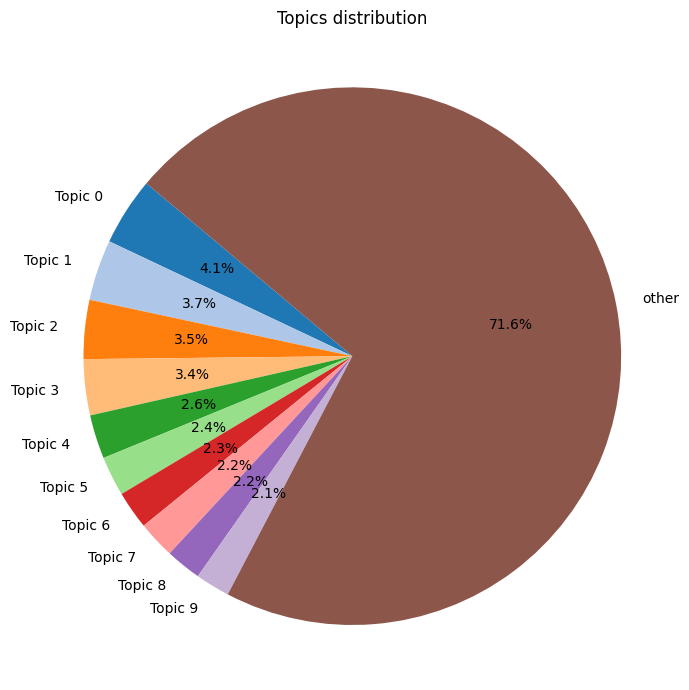

In [193]:
all_topics = topic_model_question.get_topic_info().to_records(index=False)
all_topics = [(row.Topic, row.Count, topic_model_question.get_topic(row.Topic)) for row in all_topics if row.Topic != -1]

top_10_topics = sorted(all_topics, key=lambda x: x[1], reverse=True)[:10]
other = sorted(all_topics, key=lambda x: x[1], reverse=True)[10:]

total_count = sum(count for _, count, _ in other)

labels = [f"Topic {topic_id}" for topic_id, _, _ in top_10_topics] + ['other']
sizes = [count for _, count, _ in top_10_topics] + [total_count]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Topics distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()


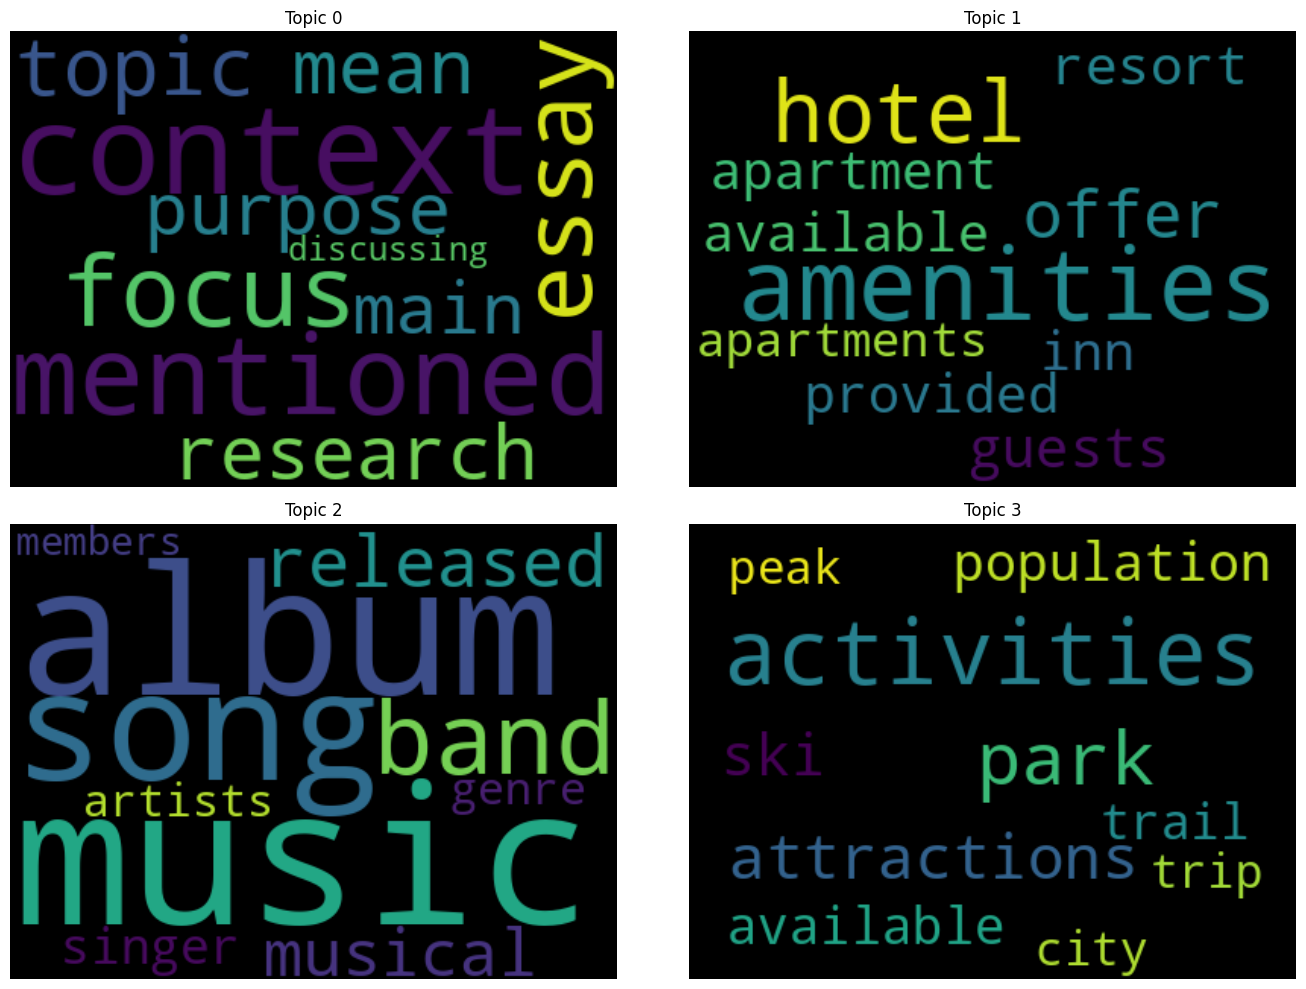

In [194]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (topic_id, _, keywords) in enumerate(top_4):
    word_freq = {word: weight for word, weight in keywords}
    wc = WordCloud(width=400, height=300, background_color='black').generate_from_frequencies(word_freq)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"Topic {topic_id}")

plt.tight_layout()
plt.show()

## Bert 

In this section and in the following we are going to use the tokenizer provided by the libraries.

In [195]:
from transformers import AutoTokenizer, BertForNextSentencePrediction

bert_model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert = BertForNextSentencePrediction.from_pretrained("bert-base-uncased", output_attentions=True).to(device) # we need output_attentions = True for visualization 

n_params = sum(param.numel() for param in bert.parameters())
print(f"This model has {n_params} paramaters")

This model has 109483778 paramaters


In [196]:
bert

BertForNextSentencePrediction(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

We have the:
1. Embeddings layer
- word embeddings (30522 x 768)
- positional embeddings (512 x 768)
- token type (2 X 768)
- layer norm (768 x 768)
2. 12x Encoders layers each one including
- Multi-Head Self-Attention Block [...]
- Feed-Forward block
3. Pooling layer
- Poooler dense weights
- Pooler dense biases

In [197]:
print("vocabulary size: ", len(tokenizer.vocab))

vocabulary size:  30522


In [198]:
def evaluate_answers_through_BERT(train_df, max_length):

    label_tensor = torch.LongTensor([1]).to(device)
    
    count = 0
    correct = 0
    
    train_df = train_df[:max_length]

    for row in train_df.itertuples():
        if row.context and row.question and row.answer:
            text_a = row.context + " " + row.question
            text_b = row.answer
            
            encoding = tokenizer(text_a, text_b, return_tensors="pt", max_length=512, truncation=True).to(device)

            with torch.no_grad():
                outputs = bert(**encoding, labels=label_tensor)
                logits = outputs.logits
                # print(f"{count} {logits}")
                if logits[0][0].item() > logits[0][1].item():
                    correct += 1

            count += 1

    return correct / count if count > 0 else 0


In [199]:
correct_answers = evaluate_answers_through_BERT(train_df, 100) # only evaluated on 100 samples otherwise it is really slow
print(f"Percentage of correct answers: {correct_answers * 100} %")

Percentage of correct answers: 100.0 %


### Semantic Search with RoBerta

In [204]:
from sentence_transformers import SentenceTransformer, util
roberta = SentenceTransformer('all-distilroberta-v1')

In [ ]:
question_roberta_embeddings = roberta.encode(train_df['question'], convert_to_tensor=True)
context_roberta_embeddings = roberta.encode(train_df['context'], convert_to_tensor=True)
answer_roberta_embeddings = roberta.encode(train_df['answer'], convert_to_tensor=True)

normalized_question_embeddings = util.normalize_embeddings(question_roberta_embeddings)
normalized_context_embeddings = util.normalize_embeddings(context_roberta_embeddings) 
normalized_answer_embeddings = util.normalize_embeddings(answer_roberta_embeddings)

Batches:   0%|          | 0/300 [00:00<?, ?it/s]

Batches:   0%|          | 0/300 [00:00<?, ?it/s]

In [218]:
hits = util.semantic_search(normalized_question_embeddings, normalized_context_embeddings, score_function=util.dot_score)

NameError: name 'normalized_context_embeddings' is not defined

In [ ]:
queries = ['What are the main benefits of having available clean water resources?']

top_k = min(5, len(question_roberta_embeddings))
for query in queries:
    query_embedding = roberta.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_embedding, question_roberta_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    print(f"Query: \"{query}\"")
    print("Top 5 most similar sentences in corpus:\n\n")
    for score, idx in zip(top_results[0], top_results[1]):
        idx = idx.item()  # Convert tensor to int
        print(f"Score: {score:.2f} - Document: \"{train_df['question'].iloc[idx]}\"")
    print("\n\n\n\n")


## Encoder - Decoder architectures

* Data preparation – Load neural-bridge/rag-dataset-12000 and drop any record with empty question, context or answer.

* Dataset & tokenizer – Wrap samples in a QADataset; encode with bert-base-uncased (≤512 tokens) and feed to train/test DataLoaders.

* Seq2Seq LSTM model – Shared embedding → encoder LSTM → decoder LSTM → linear vocab head; trained end-to-end.

* Training / inference – Optional 200-epoch run (Adam 1e-3, CE loss) or load a pre-trained checkpoint for quick evaluation.

* Metrics & baselines – Report EM, BLEU-2, ROUGE-1/L for the LSTM and compare against FLAN-T5 in four QA modes (zero/few-shot × with/without context).

**Importing the dataset and removing Nulls**

In [ ]:
from datasets import load_dataset

dataset = load_dataset("neural-bridge/rag-dataset-12000")

# Define a function to keep only valid examples
def is_valid(example):
    return all([
        example["question"] is not None and example["question"].strip() != "",
        example["context"] is not None and example["context"].strip() != "",
        example["answer"] is not None and example["answer"].strip() != ""
    ])

# Apply filtering
dataset = dataset.filter(is_valid)

**Defining dataset and dataset loader classes for LSTM**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class QADataset(Dataset):
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_text = f"question: {item['question']} context: {item['context']}"
        target_text = item['answer']

        input_ids = self.tokenizer.encode(input_text, truncation=True, padding="max_length", max_length=self.max_length)
        target_ids = self.tokenizer.encode(target_text, truncation=True, padding="max_length", max_length=64)

        return {
            "input_text": input_text,
            "target_text": target_text,
            "input_ids": torch.tensor(input_ids),
            "target_ids": torch.tensor(target_ids)
        }

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")  # can be any tokenizer with .encode/.pad capabilities
max_length = 512

train_dataset = QADataset(dataset['train'], tokenizer, max_length)
test_dataset = QADataset(dataset['test'], tokenizer, max_length)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

**Defining LSTM model**

In [ ]:
import torch
import torch.nn as nn

class Seq2SeqLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Seq2SeqLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.encoder = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_ids, target_ids):
        embedded_inputs = self.embedding(input_ids)
        _, (hidden, cell) = self.encoder(embedded_inputs)

        embedded_targets = self.embedding(target_ids)
        outputs, _ = self.decoder(embedded_targets, (hidden, cell))

        logits = self.fc(outputs)
        return logits

**Train loop**

The following loop is optional, another option is to simply load the model

In [ ]:
def train_model(model, criterion, optimizer, vocab_size, device, trian_loader):
    for epoch in range(200):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader):
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, target_ids[:, :-1])
            loss = criterion(outputs.reshape(-1, vocab_size), target_ids[:, 1:].reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
        print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader)}")

    torch.save(model, 'model.pt')

Since it takes some time to train the model, we are going to load a pre-trained version

In [ ]:
from tqdm import tqdm

TRIANING = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if (TRIANING):
    print('Model trainin start: ')
    vocab_size = tokenizer.vocab_size
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model = Seq2SeqLSTM(vocab_size, embed_size=256, hidden_size=512).to(device)

    train_model(model, criterion, optimizer, vocab_size, device, train_loader)
else:
    print('Loading model:')
    model = torch.load('/kaggle/input/lstm-pretrained-model/pytorch/default/1/model.pt')
    print(model)

In [ ]:
def eval_model(model, scorer, device, test_loader):
    model.eval()

    rouge1_scores = []
    rougeL_scores = []
    em_scores = []
    bleu_scores = []
    
    texts = []
    predictions = []
    references = []
    
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        target_ids = batch["target_ids"].to(device)
    
        # Inference
        with torch.no_grad():
            embedded_inputs = model.embedding(input_ids)
            _, (hidden, cell) = model.encoder(embedded_inputs)
    
            decoder_input = target_ids[:, 0].unsqueeze(1)  # first token (e.g. <start>)
            outputs = []
    
            # predicts all characters in the sentence
            for t in range(1, target_ids.shape[1]):
                embedded = model.embedding(decoder_input)
                output, (hidden, cell) = model.decoder(embedded, (hidden, cell))
                logits = model.fc(output.squeeze(1))
                predicted = logits.argmax(1)
                outputs.append(predicted.unsqueeze(1))
                decoder_input = predicted.unsqueeze(1)
    
            outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len - 1)
    
        texts += batch['input_text']
        # Convert outputs to text
        for pred_ids, true_ids in zip(outputs, target_ids[:, 1:]):
            pred_tokens = [token.item() for token in pred_ids if token.item() != tokenizer.pad_token_id]
            true_tokens = [token.item() for token in true_ids if token.item() != tokenizer.pad_token_id]
    
            pred_text = tokenizer.decode(pred_tokens, skip_special_tokens=True).strip()
            true_text = tokenizer.decode(true_tokens, skip_special_tokens=True).strip()
    
            references.append(true_text)
            predictions.append(pred_text)
    
            # Exact Match
            em = int(pred_text == true_text)
            em_scores.append(em)
    
            # BLEU
            ref = [true_text.split()]
            hyp = pred_text.split()
            bleu = sentence_bleu(ref, hyp, weights=(0.5, 0.5))  # BLEU-2
            bleu_scores.append(bleu)
    
            # ROUGE
            rouge = scorer.score(true_text, pred_text)
            rouge1_scores.append(rouge["rouge1"].fmeasure)
            rougeL_scores.append(rouge["rougeL"].fmeasure)

    return rouge1_scores, rougeL_scores, em_scores, bleu_scores, texts, predictions, references

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from torch.nn.functional import softmax
from rouge_score import rouge_scorer


scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
rouge1_scores, rougeL_scores, em_scores, bleu_scores, texts, predictions, references = eval_model(model, scorer, device, test_loader)

In [ ]:
print(f"Exact Match (EM): {sum(em_scores)/len(em_scores):.4f}")
print(f"BLEU Score: {sum(bleu_scores)/len(bleu_scores):.4f}")
print(f"Rouge1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"RougeL: {sum(rougeL_scores)/len(rougeL_scores):.4f}")

#### T5 model evaluation

In [ ]:
def construct_prompt(example, context=True, few_shot=False, shots=[]):
    prompt = ""
    if few_shot:
        for ex in shots:
            prompt += f"question: {ex['question']}\n"
            if context:
                prompt += f"context: {ex['context']}\n"
            prompt += f"answer: {ex['answer']}\n\n"
    prompt += f"question: {example['question']}\n"
    if context:
        prompt += f"context: {example['context']}"
    return prompt.strip()

In [ ]:
def evaluate_llm(test_set, train_set, scorer, context=True, few_shot=False, k=0, max_eval=50):
    predictions = []
    references = []
    rouge1_scores = []
    rougeL_scores = []
    
    shot_examples = train_set.select(range(k)) if few_shot and k > 0 else []

    for i, example in enumerate(test_set.select(range(max_eval))):  # limit for speed
        shots = [shot_examples[j] for j in range(k) if j != i] if few_shot else []
        prompt = construct_prompt(example, context=context, few_shot=few_shot, shots=shots)

        try:
            output = generator(prompt, max_length=64, clean_up_tokenization_spaces=True)[0]['generated_text'].strip()
        except Exception as e:
            print(f"Skipping example {i} due to error: {e}")
            continue

        predictions.append(output)
        references.append(example["answer"].strip())
        rouge = scorer.score(example["answer"].strip(), output)
        rouge1_scores.append(rouge["rouge1"].fmeasure)
        rougeL_scores.append(rouge["rougeL"].fmeasure)
    
    return rouge1_scores, rougeL_scores

In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM, AutoTokenizer
import evaluate

model_checkpoint = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
generator = pipeline("text2text-generation", model=model, tokenizer=tokenizer)

In [ ]:
test_set = dataset['test']
train_set = dataset['train']


# ---------- Run All 4 Evaluation Modes ----------
print("\n🧪 Evaluating all 4 QA modes with ROUGE (first 50 examples):\n")

print("No-context Zero-shot")
rouge1_scores, rougeL_scores = evaluate_llm(test_set,train_set, scorer, context=False, few_shot=False, max_eval=20)
print(f"Rouge1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"RougeL: {sum(rougeL_scores)/len(rougeL_scores):.4f}")


print("\nNo-context Few-shot")
rouge1_scores, rougeL_scores =evaluate_llm(test_set,train_set,scorer, context=False, few_shot=True, k=2, max_eval=20)
print(f"Rouge1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"RougeL: {sum(rougeL_scores)/len(rougeL_scores):.4f}")


print("\nWith-context Zero-shot")
rouge1_scores, rougeL_scores = evaluate_llm(test_set,train_set,scorer, context=True, few_shot=False, max_eval=20)
print(f"Rouge1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"RougeL: {sum(rougeL_scores)/len(rougeL_scores):.4f}")


print("\nWith-context Few-shot")
rouge1_scores, rougeL_scores = evaluate_llm(test_set,train_set,scorer, context=True, few_shot=True, k=2, max_eval=20)
print(f"Rouge1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"RougeL: {sum(rougeL_scores)/len(rougeL_scores):.4f}")

## LLM evaluation

In [ ]:
from tqdm import tqdm
from nltk import sent_tokenize
from rouge_score import rouge_scorer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from datasets import load_dataset
from huggingface_hub import login
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, T5Tokenizer, T5ForConditionalGeneration, BitsAndBytesConfig
from langchain.schema import Document  
from langchain import HuggingFacePipeline
from langchain import PromptTemplate, LLMChain

import gc
import torch 
import random
import faiss
import numpy as np

In [ ]:
#Hugging Face
os.environ["HUGGINGFACEHUB_API_TOKEN"] = "chiave"  # huggingface api key"
login("chiave")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# LLM definition
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"#"microsoft/Phi-3-mini-4k-instruct" # "Qwen/Qwen1.5-0.5B"

model_LLM = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name) # use the same model

#define the pipeline
generator = pipeline("text-generation", model=model_LLM, tokenizer=tokenizer)

In [ ]:
model_sentence = SentenceTransformer('all-MiniLM-L6-v2', device = device)

In [ ]:
model_LLM.eval()  # set to eval mode (no dropout etc.)

#### QA 

In [ ]:
def ask_llm(question, context, prompt): 
    '''
        INPUT a question and its releated context, and a prompt (zero, one, few shot),
        OUTPUT the answer
    '''
    
    # code used in the exercises session that work if we have pipeline
    user_request = "\nAnswer the question based only on the context below. \nContext " + context + "\nQuestion:" + question +"\nAnswer:"
    
    prompt = "You are a helpful assistant. " + prompt
    messages = [
        {"role": "system", "content": prompt},
        {"role": "user", "content": user_request},
    ]
    
    generation_args = {
        "max_new_tokens": 256,
        "return_full_text": False,
        "temperature": 0.0,
        "do_sample": False,
    }

    messages = generator.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    with torch.no_grad():  # disable gradient computation!
        output = generator(messages, **generation_args)

    return output[0]['generated_text']

##### Evaluation 
**Cosine similarity** between the generated answer and the original one

In [ ]:
def compute_similarity(original_answer, generated_answer): 
    original_embedding = model_sentence.encode(original_answer, convert_to_tensor=True)#, batch_size = 32)
    gen_embedding = model_sentence.encode(generated_answer, convert_to_tensor=True)#, batch_size = 32)
    
    cosine_sim = util.pytorch_cos_sim(original_embedding, gen_embedding).item()
    
    return cosine_sim

**RougeL** and **Rouge1** 

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_answer(predicted_answer, reference_answer):
    scores = scorer.score(reference_answer, predicted_answer)
    return scores

##### Zero or One Shot?

In [ ]:
def get_token_len(example): # Function to compute token length
    tokens = tokenizer(example["context"], truncation=False)
    return len(tokens["input_ids"])

lengths = [get_token_len(train[i]) for i in range(len(train))] # Compute token lengths for each example

sorted_indices = sorted(range(len(lengths)), key=lambda i: lengths[i]) # Sort indices by length

In [ ]:
#function that returns the one shot prompt with an example of Q-A
def create_one_shot_prompt(context, question):   
    shortest_sample = train[sorted_indices[0]]  # Shortest example
    context_sample = shortest_sample["context"]
    question_sample = shortest_sample["question"]
    answer_sample = shortest_sample["answer"]
    
    return f"Example: \n Context: {context_sample} \nQuestion: {question_sample} \nAnswer: {answer_sample}"

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
results = {
    "zero_shot": [],
    "one_shot": []
}

total_rougeL_zero = []
total_rougeL_one = []

for row in tqdm(test.select(range(1000))):
    context = row['context']
    question = row['question']
    reference_answer = row['answer']

    prompt_zero = ""    #zero shot prompt
    prompt_one = create_one_shot_prompt(context, question)    #one_shot_prompt

    # Answer the question given the context in zero/one shot
    generated_answer_zero = ask_llm(question, context, prompt_zero)
    generated_answer_one = ask_llm(question, context, prompt_one)

    # Cosine similarity
    score_zero = compute_similarity(reference_answer, generated_answer_zero)
    score_one = compute_similarity(reference_answer, generated_answer_one)
    
    results["zero_shot"].append(score_zero)
    results["one_shot"].append(score_one)
    
    # RougeL and rouge1
    rougeL_zero = evaluate_answer(generated_answer_zero, reference_answer)
    rougeL_one = evaluate_answer(generated_answer_one, reference_answer)
          
    total_rougeL_zero.append(rougeL_zero)
    total_rougeL_one.append(rougeL_one)

In [ ]:
print("Last example:")
print("\n Generated ans zero ", generated_answer_zero)
print("\n Generated ans one ", generated_answer_one)

print("\n Reference ans ", reference_answer)
print("\n Question  ", question)
print("\n Context ", context)
print(f"\n Results: \n rouge zero {rougeL_zero},\n rouge one {rougeL_one},\n score zero {round(score_zero, 4)},\n score one {round(score_one, 4)}") 

In [ ]:
#Results
print("Cosine similarity Zero-shot: ", np.mean(results["zero_shot"]))
print("Cosine similarity One-shot: ", np.mean(results["one_shot"]))

avg_rougeL_zero = np.mean([r["rougeL"] for r in total_rougeL_zero])
avg_rougeL_one = np.mean([r["rougeL"] for r in total_rougeL_one])

print(f"\nAverage ROUGE-L F1 Zero Shot Score: {round(avg_rougeL_zero, 4)}")
print(f"Average ROUGE-L F1 One Shot Score: {round(avg_rougeL_one, 4)}")

In [ ]:
# Clear GPU cache
torch.cuda.empty_cache()

##### Quantized Model for Inference


In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

In [ ]:
model_name = "mistralai/Mistral-7B-Instruct-v0.1" 
model_4bit = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto",quantization_config=quantization_config, )
tokenizer = AutoTokenizer.from_pretrained(model_name)

model_4bit.eval()

In [ ]:
pipeline_inst = pipeline(
        "text-generation",
        model=model_4bit,
        tokenizer=tokenizer,
        use_cache=True,
        device_map="auto",
        max_length=2500,
        truncation=True,
        do_sample=True,
        top_k=5,
        num_return_sequences=1,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
)

llm = HuggingFacePipeline(pipeline=pipeline_inst)

Zero shot

In [ ]:
template = """You are a respectful and helpful assistant. 
                Context: {context}
                Question: {question}
                Answer:"""

In [ ]:
prompt = PromptTemplate(template=template, input_variables=["context", "question"])
llm_chain = LLMChain(prompt=prompt, llm=llm)

def generate_response(context, question):
    output = llm_chain.run({"context": context, "question": question})
    
    output = output.strip()    # Normalize spacing
    
    # Try to isolate the answer
    if "Answer:" in output:
        return output.split("Answer:")[-1].strip()
    else: 
        return output

One shot

In [ ]:
template_one = """You are a respectful and helpful assistant. 
                Example of question answering: context: {context_ex}, question: {question_ex}, answer: {answer_ex}. \n
                Context: {context}
                Question: {question}
                Answer:"""

In [ ]:
prompt_one = PromptTemplate(template=template, input_variables=["context_ex","question_ex", "answer_ex", "context", "question"])
llm_chain_one = LLMChain(prompt=prompt_one, llm=llm)

# Shortest example for one shot
shortest_sample = train[sorted_indices[0]] 
context_ex = shortest_sample["context"]
question_ex = shortest_sample["question"]
answer_ex = shortest_sample["answer"]

def generate_response_one(context, question):
    output = llm_chain_one.run({"context_ex":context_ex, "question_ex": question_ex, "answer_ex": answer_ex, "context": context, "question": question})
    
    output = output.strip()    # Normalize spacing
    
    # Try to isolate the answer
    if "Answer:" in output:
        return output.split("Answer:")[-1].strip()
    else: 
        return output

Comparing zero and few shot

In [ ]:
total_rougeL_zero = []
total_rougeL_one = []

for row in tqdm(test.select(range(1000))):
    if not row['question'] or not row['answer']:
        continue
    output_zero = generate_response(row['context'], row['question'])
    output_one = generate_response_one(row['context'], row['question'])
    
    # RougeL and rouge1
    rougeL_zero = evaluate_answer(output_zero, row['answer'])
    rougeL_one = evaluate_answer(output_one, row['answer'])
          
    total_rougeL_zero.append(rougeL_zero)
    total_rougeL_one.append(rougeL_one)

In [ ]:
print("Last example:")
print("\n Generated ans zero ", output_zero)
print("\n Generated ans one ", output_one)

print("\n Reference ans ", row['answer'])
print("\n Question  ", row['question'])
print("\n Context ", row['context'])
print(f"\n Results: \n rouge zero {rougeL_zero},\n rouge one {rougeL_one}"

In [ ]:
#Results
avg_rougeL_zero = np.mean([r["rougeL"] for r in total_rougeL_zero])
avg_rougeL_one = np.mean([r["rougeL"] for r in total_rougeL_one])

print(f"\nAverage ROUGE-L F1 Zero Shot Score: {round(avg_rougeL_zero, 4)}")
print(f"Average ROUGE-L F1 One Shot Score: {round(avg_rougeL_one, 4)}")

# Extensions

## Chatbot

We created a web application using Streamlit that is available at https://chatbot-m4btjtwos4j.streamlit.app/. \
The web app is divided into 2 sections. \
The first section contains a chatbot built on top of Meta's model Llama 3.1 8B Instruct which is a general purpose chatbot. \
The second section contains a button that randomly chooses a question and answer pair from our dataset that sends the question through an API request and then displays the answer from the model side by side with the answer stored in the dataset.


## RAG
We consider all the context provided in the dataset as our documents, since the original dataset "tiiuae/falcon-refinedweb" is too large to be used directly.

Therefore, we begin by splitting these documents (contexts) into smaller chunks.

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap  = 200,
    length_function = len,
    separators = [";", ".", ","]
)

all_docs = []
for row in tqdm(train):
    doc = Document(page_content=row['context'])
    all_docs.append(doc)

for row in tqdm(test):
    doc = Document(page_content=row['context'])
    all_docs.append(doc)
  
split_documents = text_splitter.split_documents(all_docs)

Embedding chunks: Each text chunk is converted into a numerical vector using a pre-trained language model. These vectors capture the semantic meaning of the text, enabling similarity-based retrieval for relevant information during question answering.

In [ ]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

chunks = [doc.page_content for doc in split_documents]

embeddings = embedder.encode(chunks, convert_to_numpy=True, show_progress_bar=True)
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

This function takes a user question, encodes it into an embedding, and compares it with the embeddings of the document chunks. It retrieves the most relevant chunks based on similarity and returns the retrieved context.

In [ ]:
def rag_retrieve_context(question, k=3):
    # Embed the question and retrieve the top-k relevant contexts
    q_embedding = embedder.encode([question])
    _, top_indices = index.search(q_embedding, k=k)
    
    # Select and join retrieved contexts (if k > 1)
    context = "\n\n".join([chunks[i] for i in top_indices[0]])
    
    return context

We verify the overlap between the retrieved and original context by measuring how many chunks from the retrieved_context are found within the original_context.

In [ ]:
def overlap_percentage(retrieved_context, original_context):
    original_clean = original_context.lower().strip()
    match_count = sum(1 for chunk in retrieved_context if chunk.lower().strip() in original_clean)
    return (match_count / len(retrieved_context)) * 100 if retrieved_context else 0

Finally use the RAG on the test set

In [ ]:
total_score = []
subset_matches = 0
overlap_scores = []
total_samples = 0

for row in tqdm(test.select(range(1000))): 
    if 'question' not in row or row['question'] is None:
        continue  # skip malformed rows

    question = row['question']
    ground_truth = row['answer']
    original_context = row['context']

    #RAG 
    retrieved_context = rag_retrieve_context(question)
    generated_answer = ask_llm(question, retrieved_context, "")  # LLM answers the question given the retrieved context
    
    score = evaluate_answer(generated_answer, ground_truth)  # ROUGE score
    total_score.append(score)

    # Overlap percentage
    overlap = overlap_percentage(retrieved_context, original_context)
    overlap_scores.append(overlap)
    total_samples += 1

In [ ]:
print("Last example:")
print("\n Generated answer ", generated_answer)

print("\n Reference answer ", ground_truth)
print("\n Question  ", question)
print("\n Context ", original_context)
print(f"\n Result : {score}") 

Final statistics

In [ ]:
average_overlap = sum(overlap_scores) / len(overlap_scores) if overlap_scores else 0

print(f"Average overlap: {average_overlap:.2f}%")
print(f"Average ROUGE-L Score: {round(avg_rougeL_one, 4)}")

### Attention visualization through BERT (this is the only part needing a patch)

In [ ]:
from bertviz.neuron_view import show, head_view

i=2
q = train_df['question'][i] 
a = train_df['answer'][i]
print(q)
print(a)

model_type = 'bert'
head_view(bert, model_type, tokenizer, q, a)


In [ ]:
from bertviz.transformers_neuron_view import BertModel, BertTokenizer
from bertviz.neuron_view import show
model_type = 'bert'
model_version = 'bert-base-uncased'
do_lower_case = True
model = BertModel.from_pretrained(model_version)
tokenizer = BertTokenizer.from_pretrained(model_version, do_lower_case=do_lower_case)
sentence_a = "The cat sat on the mat"
sentence_b = "The cat lay on the rug"
show(model, model_type, tokenizer, q, a, display_mode='dark', layer=2, head=0)

# Conclusions